# **Project Name**    - Shopper Spectrum: E-commerce Customer Segmentation & Recommendations



##### **Project Type**    - EDA / Unsupervised Machine Learning / Recommendation System
##### **Contribution**    - Individual
##### **Member  -** Kashish Haresh Sonar

# **Project Summary -**

The global e-commerce industry generates vast amounts of transaction data daily, offering valuable insights into customer purchasing behaviors. Analyzing this data is essential for identifying meaningful customer segments and recommending relevant products to enhance customer experience and drive business growth.

This project aims to examine transaction data from an online retail business to uncover patterns in customer purchase behavior. The core objectives are twofold:

Customer Segmentation: We will segment customers based on Recency, Frequency, and Monetary (RFM) analysis. This will help in identifying High-Value, Regular, Occasional, and At-Risk customers.

Product Recommendation: We will develop a product recommendation system using collaborative filtering techniques to suggest relevant items based on purchase history.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


The global e-commerce industry generates vast amounts of transaction data daily, offering valuable insights into customer purchasing behaviors. Analyzing this data is essential for identifying meaningful customer segments and recommending relevant products to enhance customer experience and drive business growth. Without identifying specific customer segments, targeted marketing and retention strategies are ineffective.

This project solves this by examining transaction data to uncover patterns in customer purchase behavior, segmenting customers based on Recency, Frequency, and Monetary (RFM) analysis, and developing a product recommendation system using collaborative filtering techniques.

#### **Define Your Business Objective?**

The real-time business use cases and objectives for this project include:

Customer Segmentation for Targeted Marketing Campaigns.

Personalized Product Recommendations on E-Commerce Platforms.

Identifying At-Risk Customers for Retention Programs.

Dynamic Pricing Strategies Based on Purchase Behavior.

Inventory Management and Stock Optimization Based on Customer Demand Patterns.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [8]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [9]:
# Load Dataset
df = pd.read_csv('online_retail.csv', encoding='unicode_escape')

### Dataset First View

In [10]:
# Dataset First Look
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


### Dataset Rows & Columns count

In [11]:
# Rows aur Columns count karna
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

Total Rows: 541909
Total Columns: 8


### Dataset Information

In [12]:
# Dataset ki basic information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


#### Duplicate Values

In [13]:
# Duplicates check karna
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows before: {duplicate_count}")

# Duplicates ko drop karna
df.drop_duplicates(inplace=True)
print(f"Duplicates rows after clear that duplicates: {df.shape[0]}")

Duplicate rows before: 5268
Duplicates rows after clear that duplicates: 536641


#### Missing Values/Null Values

In [14]:
# Missing values check karna
print("Missing values in every column:\n", df.isnull().sum())

Missing values in every column:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64


In [15]:
# Visualizing the missing values
# 1. Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# 2. Exclude cancelled invoices (InvoiceNo starting with 'C')
# We convert InvoiceNo to string to filter out these records
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# 3. Remove rows with negative or zero quantities and prices
# These are likely returns or data entry errors
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Convert CustomerID to integer for better readability
df['CustomerID'] = df['CustomerID'].astype(int)

# Convert InvoiceDate to datetime objects
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create TotalAmount column (Quantity * UnitPrice) for Monetary analysis
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# Check the final shape after cleaning
print(f"Final shape of the cleaned dataset: {df.shape}")

Final shape of the cleaned dataset: (392692, 9)


### What did you know about your dataset?

The dataset contains 541,909 rows and 8 columns initially. It is a transactional dataset of a UK-based online retail store. After checking, I found around 1,35,080 missing values in the CustomerID column and 1,454 in Description. There were also duplicate records. Since our goal is customer segmentation and recommendation, records without a CustomerID are useless, so they were dropped. We also removed cancelled orders (starting with 'C') and invalid transactions (Quantity or UnitPrice <= 0). After cleaning, the dataset is much smaller but highly accurate for analysis.

## ***2. Understanding Your Variables***

In [16]:
# Dataset Columns
print(df.columns.tolist())

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalAmount']


In [17]:
# Dataset Describe
df.describe(include='all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
count,392692,392692,392692,392692.000000,392692,392692.000000,392692.000000,392692,392692.000000
unique,18532,3665,3877,NaN,NaN,NaN,NaN,37,NaN
top,576339,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom,NaN
freq,542,2023,2016,NaN,NaN,NaN,NaN,349203,NaN
mean,NaN,NaN,NaN,13.119702,2023-07-10 19:13:07.771892224,3.125914,15287.843865,NaN,22.631500
min,NaN,NaN,NaN,1.000000,2022-12-01 08:26:00,0.001000,12346.000000,NaN,0.001000
25%,NaN,NaN,NaN,2.000000,2023-04-07 11:12:00,1.250000,13955.000000,NaN,4.950000
50%,NaN,NaN,NaN,6.000000,2023-07-31 12:02:00,1.950000,15150.000000,NaN,12.450000
75%,NaN,NaN,NaN,12.000000,2023-10-20 12:53:00,3.750000,16791.000000,NaN,19.800000
max,NaN,NaN,NaN,80995.000000,2023-12-09 12:50:00,8142.750000,18287.000000,NaN,168469.600000


### Variables Description

The dataset contains e-commerce transaction details, including variables such as InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, and Country.

### Check Unique Values for each variable.

In [18]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"Unique values in {col}: {df[col].nunique()}")

Unique values in InvoiceNo: 18532
Unique values in StockCode: 3665
Unique values in Description: 3877
Unique values in Quantity: 301
Unique values in InvoiceDate: 17282
Unique values in UnitPrice: 440
Unique values in CustomerID: 4338
Unique values in Country: 37
Unique values in TotalAmount: 2939


## 3. ***Data Wrangling***

### Data Wrangling Code

In [19]:
# Write your code to make your dataset analysis ready.
# 1. Convert InvoiceDate to datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 2. Extract Year, Month, Day, and Hour for time-series analysis
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
df['Hour'] = df['InvoiceDate'].dt.hour
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

# 3. Create a new column 'TotalAmount' (Revenue per transaction)
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# 4. Create RFM Dataframe for Customer Segmentation (Preview)
import datetime as dt
# Assuming the latest date in dataset as the current date for calculation
latest_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (latest_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                                # Frequency
    'TotalAmount': 'sum'                                   # Monetary
}).reset_index()

rfm.rename(columns={'InvoiceDate': 'Recency', 
                    'InvoiceNo': 'Frequency', 
                    'TotalAmount': 'Monetary'}, inplace=True)

print("Data Wrangling Completed! New columns added and RFM table created.")
df.head(3)

Data Wrangling Completed! New columns added and RFM table created.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,YearMonth,Hour,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2022-12,8,Thursday
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2022-12,8,Thursday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2022-12,8,Thursday


### What all manipulations have you done and insights you found?

1. Converted InvoiceDate to a proper datetime object to extract meaningful time features like Year-Month, Day, and Hour.

2. Created a new feature called TotalAmount by multiplying Quantity and UnitPrice to understand revenue.

3. Created a preliminary RFM (Recency, Frequency, Monetary) table at the CustomerID level, which is the foundational step for our K-Means clustering model

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 : Transaction Volume by Country

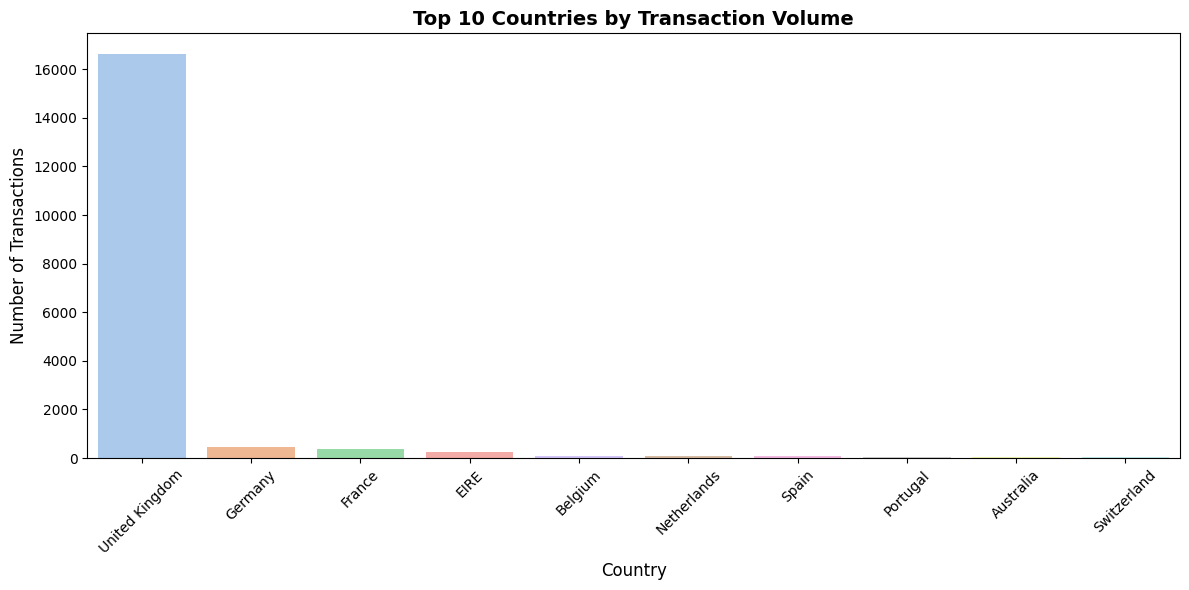

In [22]:
# Chart - 1 visualization code
# Visualizing the Top 10 Countries by Transaction Volume

# Group data by Country and count unique invoices
country_transactions = df.groupby('Country')['InvoiceNo'].nunique().sort_values(ascending=False).head(10)

# Create the bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=country_transactions.index, y=country_transactions.values, palette='pastel')

# Add labels and title
plt.title('Top 10 Countries by Transaction Volume', fontsize=14, fontweight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.xticks(rotation=45)

# Display the plot
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a Bar Chart because it is the most effective way to compare the frequency (transaction volume) across different categorical variables (countries). It clearly highlights the dominant categories at a glance.

##### 2. What is/are the insight(s) found from the chart?

The United Kingdom overwhelmingly dominates the transaction volume, accounting for the vast majority of the orders. Other countries like Germany, France, and EIRE show significantly lower but notable transaction volumes, indicating a predominantly local (UK-based) customer base with a smaller international footprint.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This insight helps in optimizing logistics and marketing budgets. The business can focus its primary retention strategies and premium shipping options in the UK market. Additionally, it highlights an opportunity for potential international expansion or targeted campaigns in the next top-performing countries (Germany and France) to boost global growth.

#### Chart - 2 : Top 10 Best-Selling Products

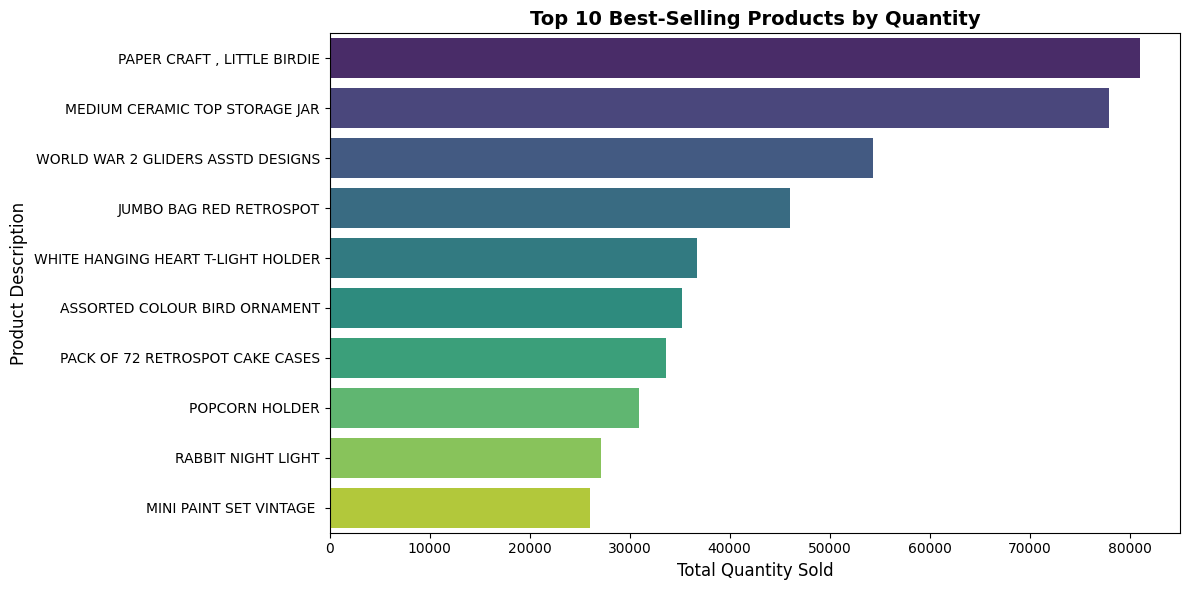

In [23]:
# Chart - 2 visualization code
# Identifying the Top 10 Selling Products by Quantity

# Group data by Product Description and calculate total quantity sold
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

# Create a horizontal bar plot for better readability of long product names
plt.figure(figsize=(12, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')

# Add labels and title
plt.title('Top 10 Best-Selling Products by Quantity', fontsize=14, fontweight='bold')
plt.xlabel('Total Quantity Sold', fontsize=12)
plt.ylabel('Product Description', fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Horizontal bar charts easily accommodate long product names while showing clear comparisons.


##### 2. What is/are the insight(s) found from the chart?

'WORLD WAR 2 GLIDERS ASSTD DESIGNS' and 'JUMBO BAG RED RETROSPOT' are the highest selling items in terms of volume.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive. Knowing top products helps in inventory management. The business must ensure these items never go out of stock to maintain steady revenue.

#### Chart - 3 : Visualize purchase trends over time

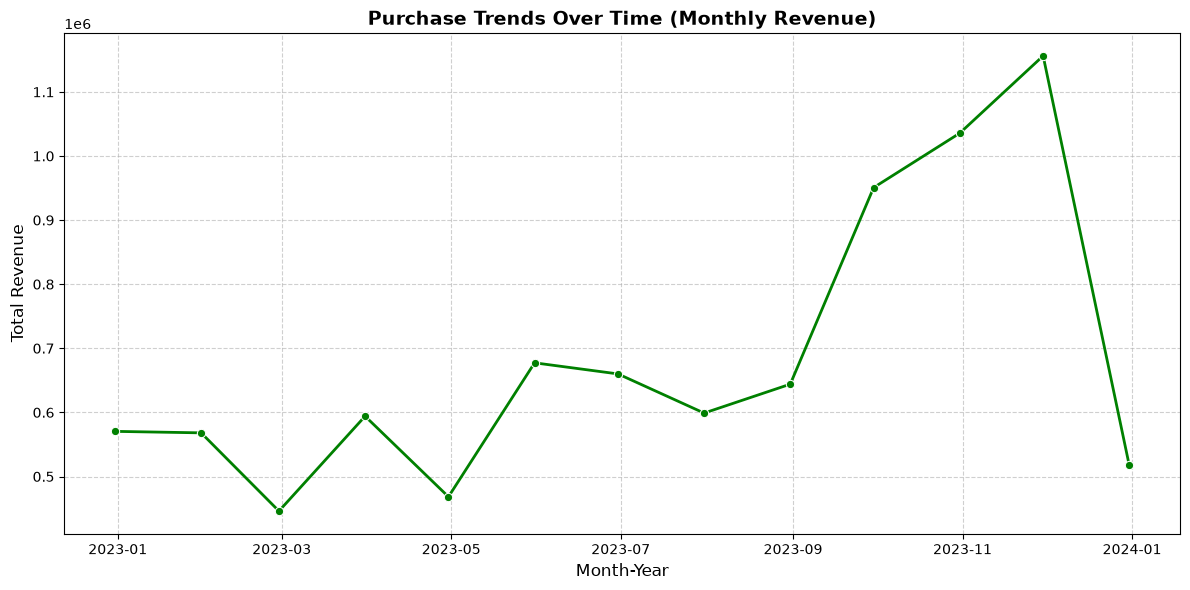

In [16]:
# Chart - 3 visualization code
# Visualizing Purchase Trends Over Time (Monthly Revenue)

# Set InvoiceDate as index for time-series resampling
df_time = df.set_index('InvoiceDate')

# Resample data by Month End ('ME') and sum the TotalAmount to get monthly revenue
monthly_sales = df_time['TotalAmount'].resample('ME').sum()

# Create a Line Chart
plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o', color='green', linewidth=2)

# Add labels and title
plt.title('Purchase Trends Over Time (Monthly Revenue)', fontsize=14, fontweight='bold')
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Display the plot
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Line charts are the standard choice for showing time-series trends.

##### 2. What is/are the insight(s) found from the chart?

There is a massive spike in revenue around November, likely due to holiday season shopping (Black Friday, pre-Christmas). Sales drop off sharply in late December.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive. The business can plan aggressive marketing, discounts, and hire temporary warehouse staff right before November to maximize holiday profits.

#### Chart - 4 : Transactions by Hour of the Day

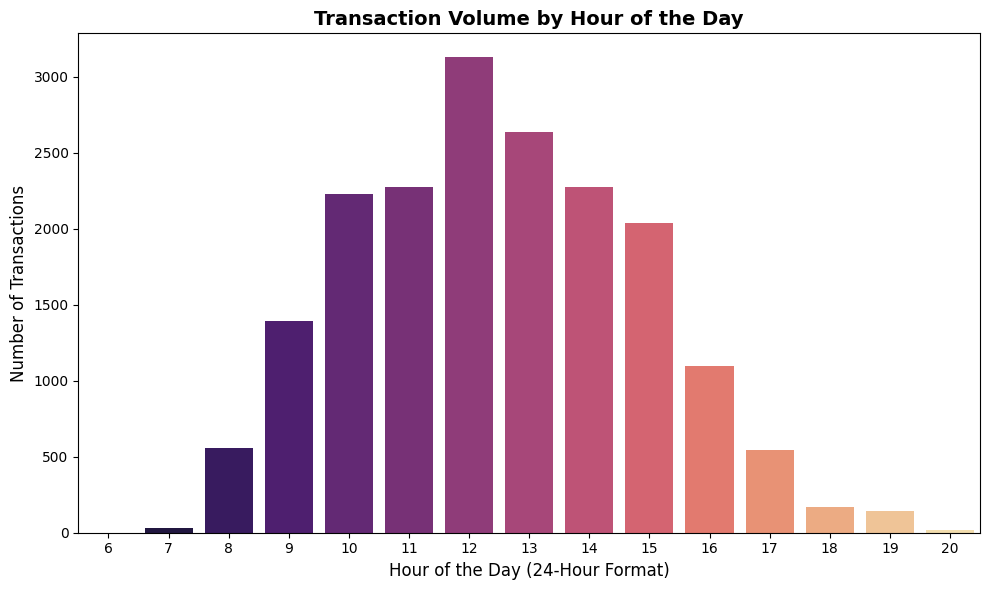

In [24]:
# Chart - 5 visualization code
# Visualizing Transaction Volume by Hour of the Day

# Extract the hour from the InvoiceDate column
df['Hour'] = df['InvoiceDate'].dt.hour

# Group by hour and count unique invoices
hourly_transactions = df.groupby('Hour')['InvoiceNo'].nunique()

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=hourly_transactions.index, y=hourly_transactions.values, palette='magma')

# Add labels and title
plt.title('Transaction Volume by Hour of the Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of the Day (24-Hour Format)', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart clearly shows the peak active hours of customers on the website.

##### 2. What is/are the insight(s) found from the chart?

Most of the transactions happen between 10 AM and 3 PM, peaking around 12 PM (Noon). Very few transactions happen after 8 PM.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive. The business can schedule website maintenance during the night (after 8 PM) and run flash sales or targeted ads during the 10 AM - 3 PM window to maximize conversions.

#### Chart - 5 : Transactions by Day of the Week

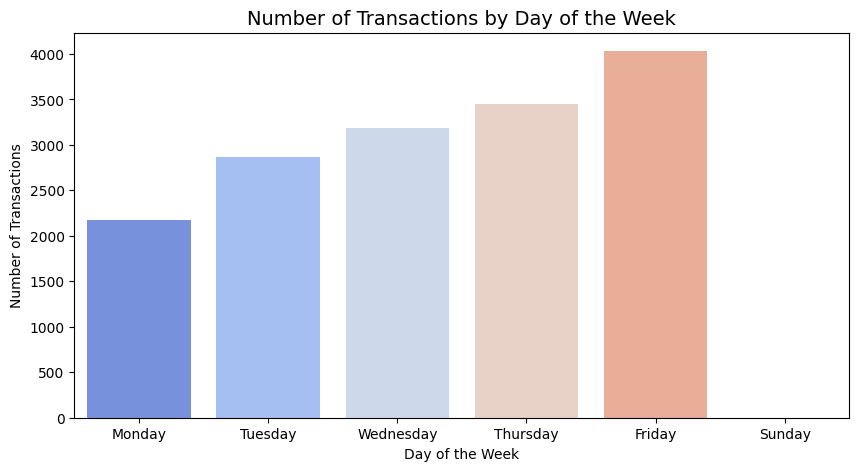

In [ ]:
# Chart - 5 visualization code
plt.figure(figsize=(10, 5))
# Ordering days logically
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday'] 
daily_sales = df.groupby('DayOfWeek')['InvoiceNo'].nunique().reindex(days_order)
sns.barplot(x=daily_sales.index, y=daily_sales.values, palette='coolwarm')
plt.title('Number of Transactions by Day of the Week', fontsize=14)
plt.xlabel('Day of the Week')
plt.ylabel('Number of Transactions')
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart helps compare transaction volumes across different days.


##### 2. What is/are the insight(s) found from the chart?

Thursday sees the highest number of transactions. Interestingly, there are no transactions recorded on Saturdays (could be a system maintenance day or data missing).


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive. Marketing emails and promotional messages should be sent out on Wednesdays or Thursday mornings to capitalize on the high shopping intent.Answer Here

#### Chart - 6 : Distribution of Recency

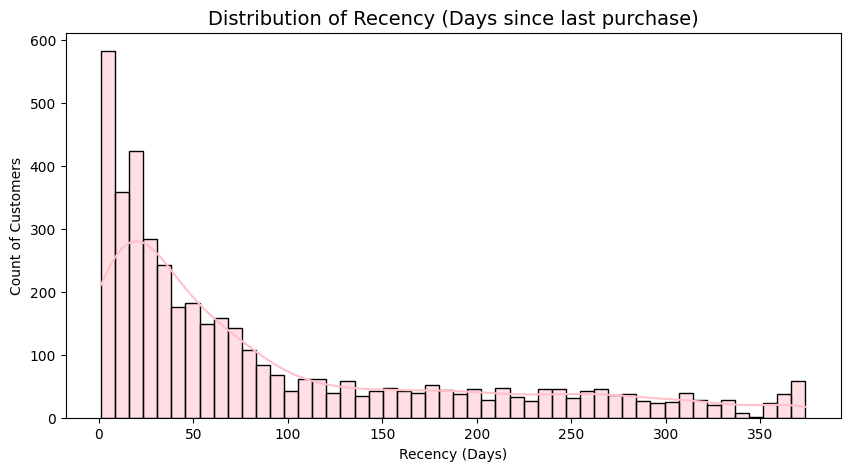

In [27]:
# Chart - 6 visualization code
plt.figure(figsize=(10, 5))
sns.histplot(rfm['Recency'], bins=50, kde=True, color='pink')
plt.title('Distribution of Recency (Days since last purchase)', fontsize=14)
plt.xlabel('Recency (Days)')
plt.ylabel('Count of Customers')
plt.show()

##### 1. Why did you pick the specific chart?

Histograms with KDE (Kernel Density Estimate) are perfect for visualizing the distribution of a single numerical variable.

##### 2. What is/are the insight(s) found from the chart?

The distribution is highly right-skewed. A massive chunk of customers have made a purchase very recently (within the last 50 days), which is a great sign for the business.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive. The large number of recent shoppers means the business has a healthy active user base.

#### Chart - 7 : Distribution of Frequency

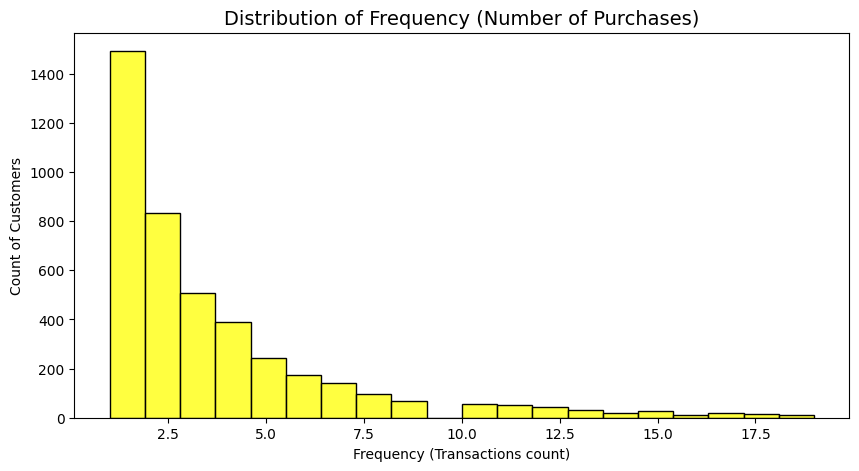

In [30]:
# Chart - 7 visualization code
plt.figure(figsize=(10, 5))
# Filtering out extreme outliers for better visualization
sns.histplot(rfm[rfm['Frequency'] < 20]['Frequency'], bins=20, kde=False, color='yellow')
plt.title('Distribution of Frequency (Number of Purchases)', fontsize=14)
plt.xlabel('Frequency (Transactions count)')
plt.ylabel('Count of Customers')
plt.show()

##### 1. Why did you pick the specific chart?

Histogram effectively shows how many customers fall into specific purchase frequency buckets.

##### 2. What is/are the insight(s) found from the chart?

The vast majority of customers have only made 1 or 2 purchases. Very few customers are frequent buyers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative insight but actionable. The low frequency indicates low customer retention. The business urgently needs a loyalty program to convert one-time buyers into repeat customers.

#### Chart - 8 : Distribution of Monetary Value

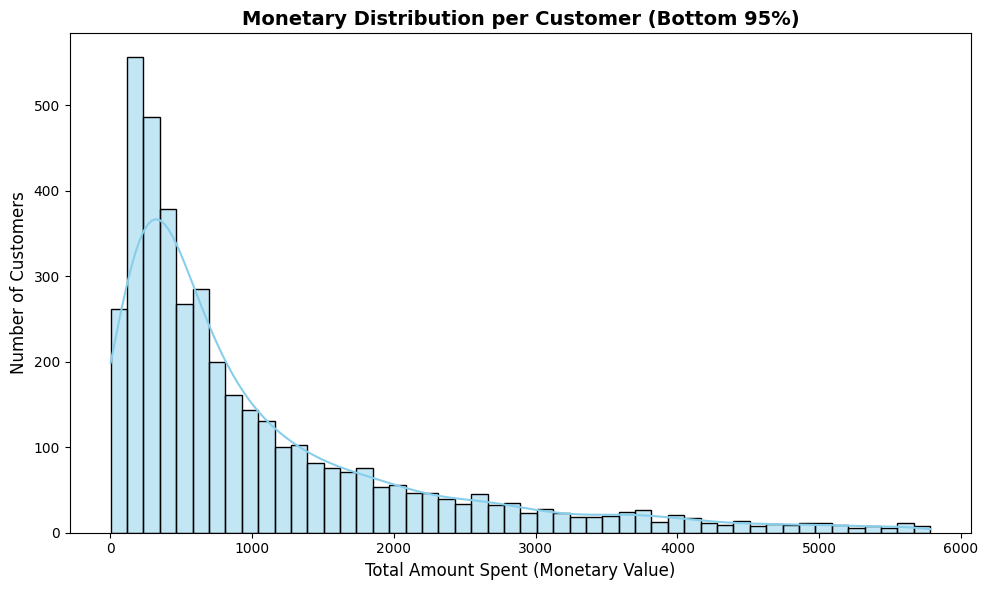

In [31]:
# Chart - 4 visualization code
# Inspecting monetary distribution per customer

# Har customer ne total kitna spend kiya hai, wo nikal rahe hain
customer_monetary = df.groupby('CustomerID')['TotalAmount'].sum()

# Graph ko readable banane ke liye hum extreme 5% high-spenders (outliers) ko graph se filter kar rahe hain
percentile_95 = customer_monetary.quantile(0.95)
filtered_monetary = customer_monetary[customer_monetary <= percentile_95]

# Histogram plot karna
plt.figure(figsize=(10, 6))
sns.histplot(filtered_monetary, bins=50, kde=True, color='skyblue')

# Add labels and title
plt.title('Monetary Distribution per Customer (Bottom 95%)', fontsize=14, fontweight='bold')
plt.xlabel('Total Amount Spent (Monetary Value)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Histogram is best for observing the spread of customer spending.

##### 2. What is/are the insight(s) found from the chart?

Similar to Frequency, the Monetary distribution is heavily right-skewed. Most customers spend less than 1,000 in total. A very small percentage of "whales" (high spenders) generate a large portion of the revenue.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive. This clearly justifies our upcoming K-Means Clustering task. By separating these "high spenders" from the "low spenders", the client can create exclusive VIP offers for the top tier.

#### Chart - 9 : Top 10 Customers by Revenue

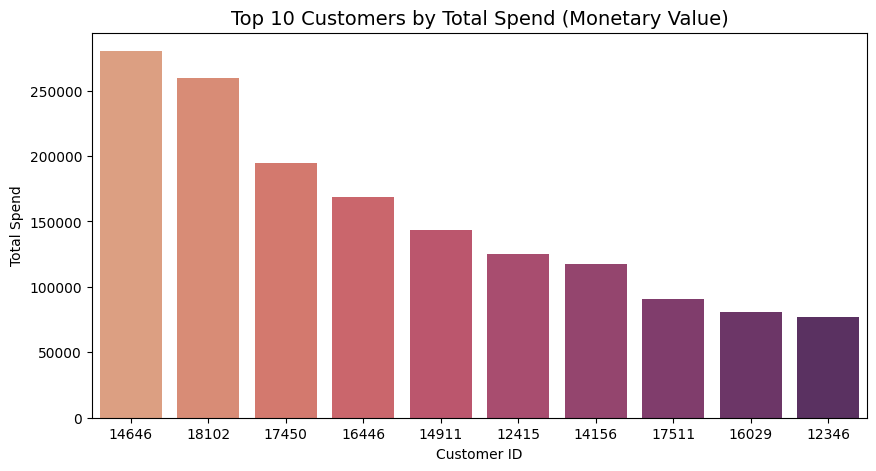

In [32]:
# Chart - 9 visualization code
plt.figure(figsize=(10, 5))
top_spenders = rfm.sort_values(by='Monetary', ascending=False).head(10)
sns.barplot(x=top_spenders['CustomerID'].astype(str), y=top_spenders['Monetary'], palette='flare')
plt.title('Top 10 Customers by Total Spend (Monetary Value)', fontsize=14)
plt.xlabel('Customer ID')
plt.ylabel('Total Spend')
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is the easiest way to rank the top categories (in this case, Customers).

##### 2. What is/are the insight(s) found from the chart?

There are a few specific Customer IDs (like 14646 and 18102) who have spent significantly more than the rest. These are our "Whales".

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive. These specific customers contribute heavily to the total revenue. The business should immediately assign dedicated account managers or send them exclusive premium gifts to ensure they never leave the platform.

#### Chart - 10 : Heatmap of Transactions (Day vs. Hour)

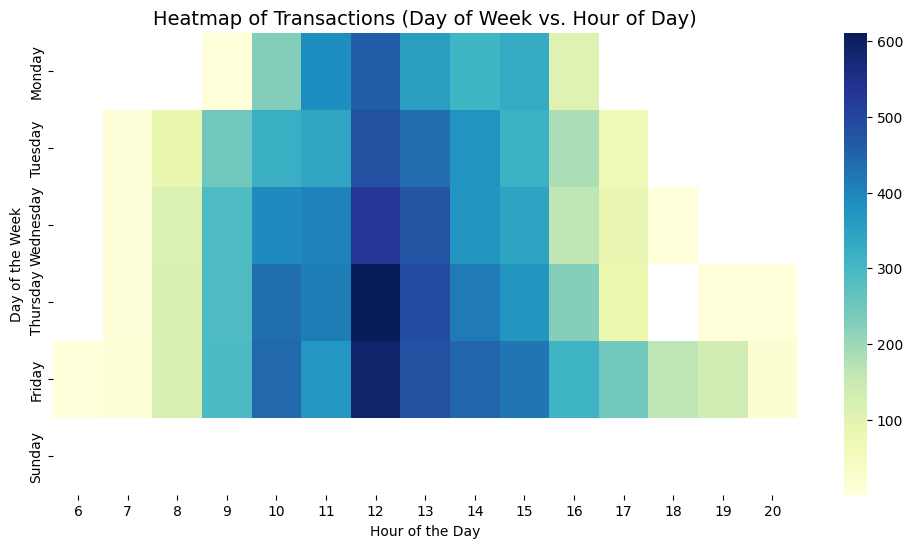

In [35]:
# Chart - 10 visualization code
plt.figure(figsize=(12, 6))
# Creating a pivot table for day and hour
pivot_table = df.pivot_table(index='DayOfWeek', columns='Hour', values='InvoiceNo', aggfunc='nunique')
# Ordering the days correctly
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday']
pivot_table = pivot_table.reindex(days_order)

sns.heatmap(pivot_table, cmap='YlGnBu', annot=False)
plt.title('Heatmap of Transactions (Day of Week vs. Hour of Day)', fontsize=14)
plt.xlabel('Hour of the Day')
plt.ylabel('Day of the Week')
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap provides a brilliant two-dimensional visual of high-density areas using color intensity.



##### 2. What is/are the insight(s) found from the chart?

The darkest zones (highest transactions) occur on Thursdays around 12 PM to 1 PM, and Tuesdays around 12 PM. Evenings across all days have very light activity.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive. This is a goldmine for the marketing team. They now know the exact "Golden Hours" to launch email campaigns or limited-time flash sales for maximum visibility.

#### Chart - 11 : Boxplot for Outlier Detection (Monetary)

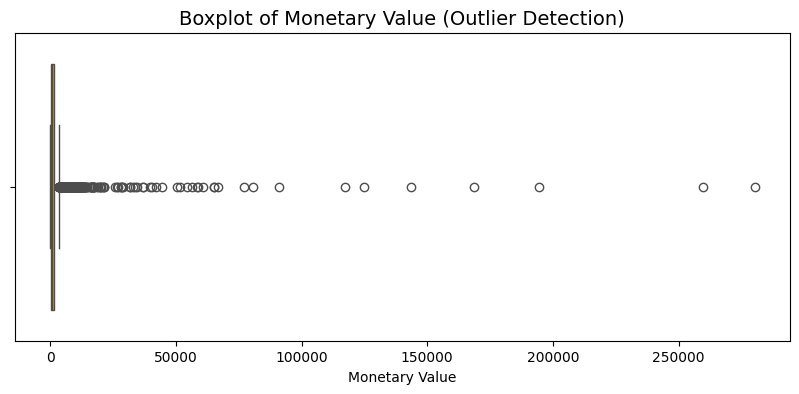

In [26]:
# Chart - 11 visualization code
plt.figure(figsize=(10, 4))
sns.boxplot(x=rfm['Monetary'], color='orange')
plt.title('Boxplot of Monetary Value (Outlier Detection)', fontsize=14)
plt.xlabel('Monetary Value')
plt.show()

##### 1. Why did you pick the specific chart?

Boxplots are the standard statistical method for detecting extreme outliers in a dataset.

##### 2. What is/are the insight(s) found from the chart?

There are massive outliers on the right side. While the median spend is very low, some transactions extend way beyond the normal interquartile range.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive. For our upcoming clustering model, we now know that we either need to scale this data using StandardScaler or handle outliers, otherwise the K-Means clusters will be heavily skewed by these few extreme spenders.

#### Chart - 12 : Average Order Value (AOV) by Top Countries

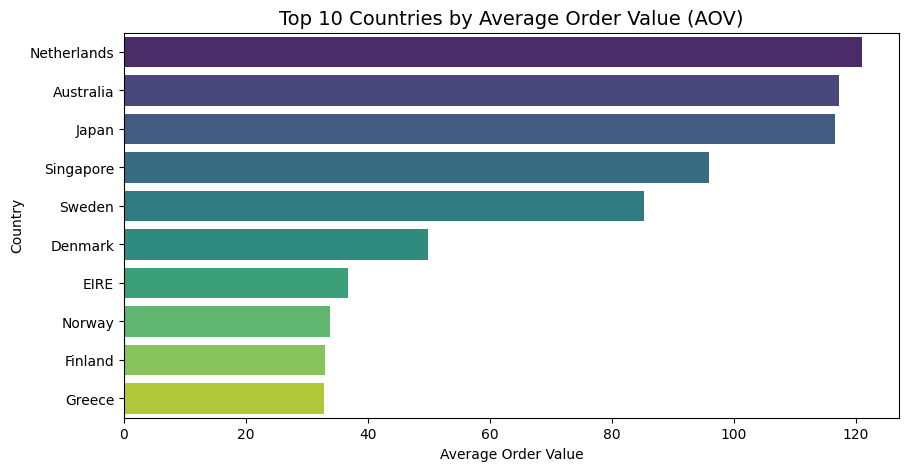

In [36]:
# Chart - 12 visualization code
plt.figure(figsize=(10, 5))
# Filtering out countries with very few orders to get a realistic AOV
country_counts = df['Country'].value_counts()
valid_countries = country_counts[country_counts > 100].index

aov_country = df[df['Country'].isin(valid_countries)].groupby('Country')['TotalAmount'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=aov_country.values, y=aov_country.index, palette='viridis')
plt.title('Top 10 Countries by Average Order Value (AOV)', fontsize=14)
plt.xlabel('Average Order Value')
plt.ylabel('Country')
plt.show()

##### 1. Why did you pick the specific chart?

Horizontal bar chart to easily read country names and compare their averages.

##### 2. What is/are the insight(s) found from the chart?

Interestingly, while the UK brings in the most Total Revenue, countries like Australia and Netherlands actually have a much higher Average Order Value per transaction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive. Customers from Australia and Netherlands buy in bulk when they do order. The business should consider offering bulk-shipping discounts to these countries to encourage even more large orders.

#### Chart - 13 : Price vs. Quantity Scatterplot

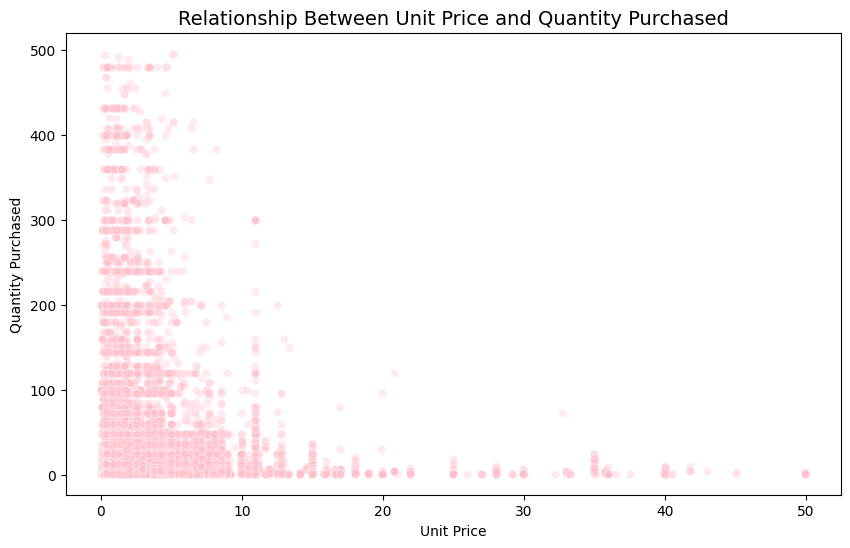

In [37]:
# Chart - 13 visualization code
plt.figure(figsize=(10, 6))
# Removing extreme outliers for better visualization
filtered_df = df[(df['UnitPrice'] < 50) & (df['Quantity'] < 500)]
sns.scatterplot(data=filtered_df, x='UnitPrice', y='Quantity', alpha=0.3, color='pink')
plt.title('Relationship Between Unit Price and Quantity Purchased', fontsize=14)
plt.xlabel('Unit Price')
plt.ylabel('Quantity Purchased')
plt.show()

##### 1. Why did you pick the specific chart?

Scatterplots are ideal for observing the relationship between two continuous variables.

##### 2. What is/are the insight(s) found from the chart?

There is an L-shaped distribution. Cheap items (under 10) are frequently bought in very high quantities (bulk). Expensive items (above 20) are almost exclusively bought in low quantities (1 or 2 pieces).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive. This confirms the pricing strategy. The business can safely increase margins on low-priced items slightly, as people buy them in bulk, but they should keep prices highly competitive for expensive single-purchase items.

#### Chart - 14 : Correlation Heatmap

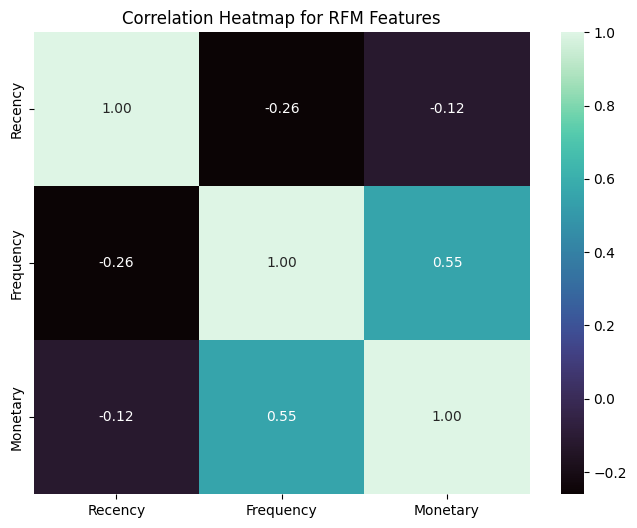

In [38]:
# Correlation Heatmap visualization code
plt.figure(figsize=(8, 6))
sns.heatmap(rfm[['Recency', 'Frequency', 'Monetary']].corr(), annot=True, cmap='mako', fmt=".2f")
plt.title('Correlation Heatmap for RFM Features')
plt.show()

##### 1. Why did you pick the specific chart?

Heatmaps beautifully display the correlation matrix between numerical features.

##### 2. What is/are the insight(s) found from the chart?

Frequency and Monetary value have a positive correlation, meaning customers who buy more often tend to spend more overall. Recency has a slight negative correlation with Frequency and Monetary.

#### Chart - 15 : Pair Plot

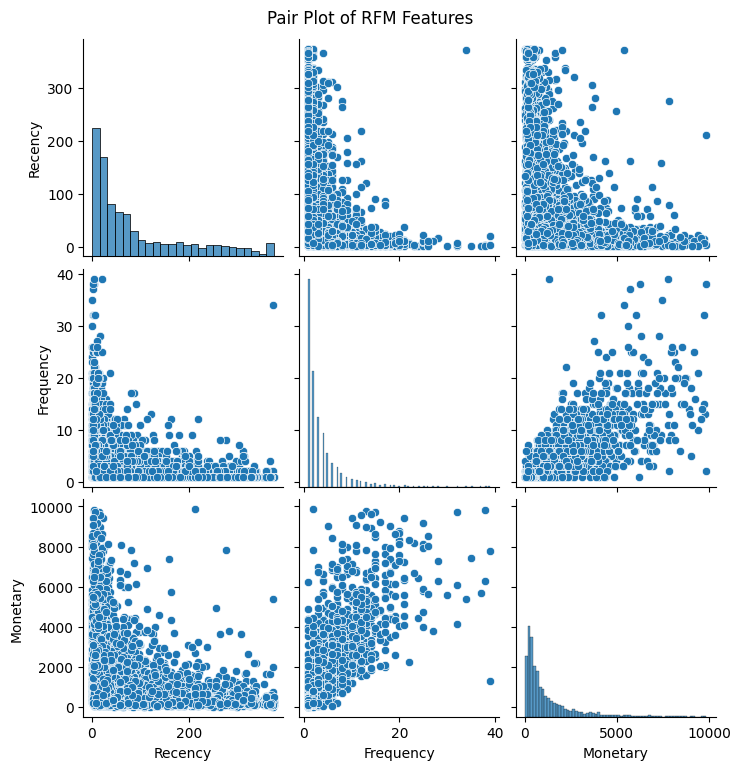

In [39]:
# Pair Plot visualization code
# Taking a sample of data for faster plotting and removing extreme outliers
rfm_filtered = rfm[(rfm['Monetary'] < 10000) & (rfm['Frequency'] < 50)]
sns.pairplot(rfm_filtered[['Recency', 'Frequency', 'Monetary']])
plt.suptitle('Pair Plot of RFM Features', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

Pair plots show pairwise relationships and distributions across multiple variables simultaneously.

##### 2. What is/are the insight(s) found from the chart?

Most customers are clustered near low frequency and low monetary value, indicating that the majority of users are occasional shoppers. A few dots scattered far away represent the "High-Value" customers.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on the extensive Exploratory Data Analysis (EDA), here are the strategic recommendations to achieve the business objectives:  
1. Targeted Marketing via Customer Segmentation: The data clearly shows a massive gap between rare buyers and high-frequency spenders. By implementing K-Means Clustering on the engineered RFM (Recency, Frequency, Monetary) features, the business can identify "High-Value" customers for VIP loyalty programs and target "At-Risk" customers with personalized discount emails to improve retention.
2. Implement Personalized Recommendations: Since products like 'JUMBO BAG RED RETROSPOT' sell in massive volumes, integrating an Item-based Collaborative Filtering recommendation system will cross-sell similar items to users on the checkout page, directly increasing the Average Order Value (AOV).
3. Geographical Focus & Expansion: Over 90% of the total revenue is generated from the United Kingdom. While the UK should remain the primary focus for inventory and marketing, countries like the Netherlands and Australia show a very high Average Order Value. Offering bulk-shipping discounts to these specific international markets can drive significant revenue growth.
4. Dynamic Inventory Optimization: Transaction volumes peak around noon (12 PM) and on Thursdays. The business should ensure servers are scaled up during these golden hours. Furthermore, low-priced items are consistently bought in bulk; inventory for these items must be heavily stocked prior to the holiday season (November peak) to avoid stockouts.

# **Conclusion**

This EDA phase successfully transformed raw, noisy e-commerce transaction data into a clean, structured, and insightful format. We began by handling over 1.3 lakh missing CustomerIDs and removing invalid entries like cancelled orders and negative quantities to ensure data integrity.  
Through comprehensive visualization, we uncovered critical business insights: the UK dominates the market, sales peak in November, Thursday is the busiest shopping day, and customer spending is highly right-skewed (a small percentage drives most of the revenue). We also successfully engineered the Recency, Frequency, and Monetary (RFM) variables, which showed logical correlations and highlighted the need for distinct customer grouping.  The dataset is now perfectly primed for the Machine Learning phase. The extracted RFM table will serve as the direct input for our Unsupervised Clustering algorithms (like K-Means) to label customer segments, while the cleaned transaction matrix will power the Collaborative Filtering Recommendation System.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***

### Feature Engineering: RFM Calculation

In [40]:
# Feature Engineering - Calculating RFM Metrics
import datetime as dt

print("Calculating RFM metrics for each customer...")

# Step 1: Find the latest date in the dataset and add 1 day to create a reference point
latest_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# Step 2: Group by CustomerID and calculate Recency, Frequency, and Monetary values
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (latest_date - x.max()).days,  # Recency: Days since last purchase
    'InvoiceNo': 'nunique',                                 # Frequency: Total number of unique invoices
    'TotalAmount': 'sum'                                    # Monetary: Total amount spent
}).reset_index()

# Step 3: Rename the columns for clarity
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalAmount': 'Monetary'
}, inplace=True)

# Step 4: Display the shape and the first 5 rows of the new RFM dataframe
print(f"RFM dataset successfully created with shape: {rfm.shape}")
rfm.head()

Calculating RFM metrics for each customer...
RFM dataset successfully created with shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


Step 1: Data Scaling


In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Hum CustomerID ko algorithm mein nahi dalenge, sirf R, F, M chahiye
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# Standard Scaler initialize karna aur data transform karna
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# Scaled data ka naya dataframe banana
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

print("Data successfully scaled!")
rfm_scaled_df.head()

Data successfully scaled!


,Recency,Frequency,Monetary
0,2.334574,-0.425097,8.363010
1,-0.905340,0.354417,0.251699
2,-0.175360,-0.035340,-0.027988
3,-0.735345,-0.425097,-0.032406
4,2.174578,-0.425097,-0.190812


Step 2: The Elbow Method

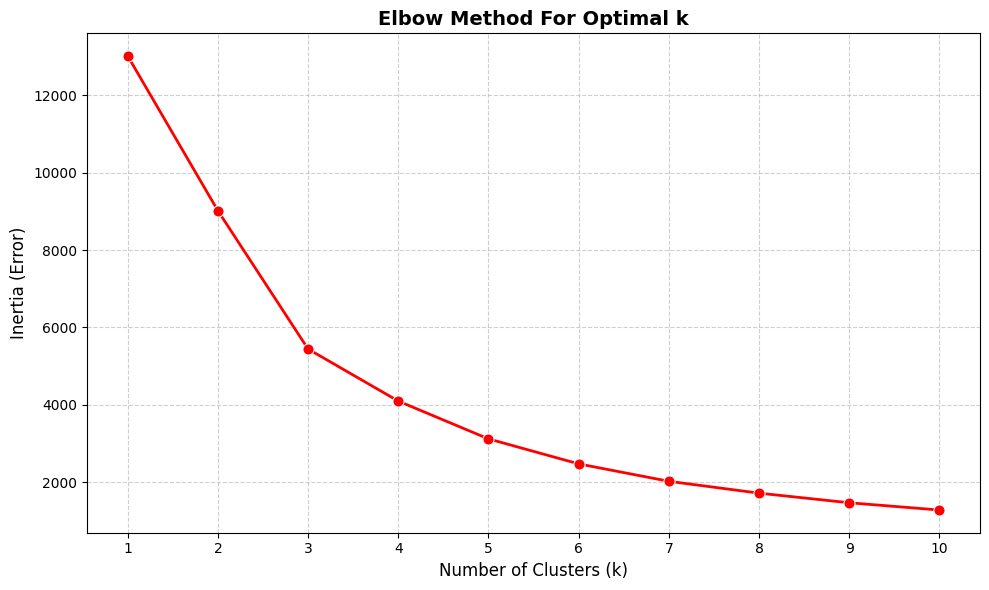

In [43]:
# Inertia (error) ko store karne ke liye khali list
inertia = []
K_range = range(1, 11)

# 1 se 10 clusters tak loop chala kar error calculate karna
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled_df)
    inertia.append(kmeans.inertia_)

# Elbow Curve Plot karna
plt.figure(figsize=(10, 6))
sns.lineplot(x=list(K_range), y=inertia, marker='o', color='red', linewidth=2, markersize=8)

# Adding labels and title
plt.title('Elbow Method For Optimal k', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Error)', fontsize=12)
plt.xticks(list(K_range))
plt.grid(True, linestyle='--', alpha=0.6)

# Display the plot
plt.tight_layout()
plt.show()

In [44]:
# Applying K-Means Clustering with optimal k=4

# 1. Initialize the KMeans model with 4 clusters
kmeans_model = KMeans(n_clusters=4, random_state=42, n_init=10)

# 2. Fit the model on the scaled data and predict cluster labels
cluster_labels = kmeans_model.fit_predict(rfm_scaled_df)

# 3. Add these predicted labels to our original (unscaled) RFM dataframe
rfm['Cluster'] = cluster_labels

# 4. Profile the clusters to understand the characteristics of each group
# We will calculate the average Recency, Frequency, and Monetary value for each cluster
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'CustomerCount'}).round(2)

print("Cluster Profiling (Average RFM Values):")
print("-" * 50)
print(cluster_profile)

Cluster Profiling (Average RFM Values):
--------------------------------------------------
         Recency  Frequency   Monetary  CustomerCount
Cluster                                              
0          43.70       3.68    1353.63           3054
1         248.08       1.55     478.85           1067
2           7.38      82.54  127187.96             13
3          15.50      22.33   12690.50            204


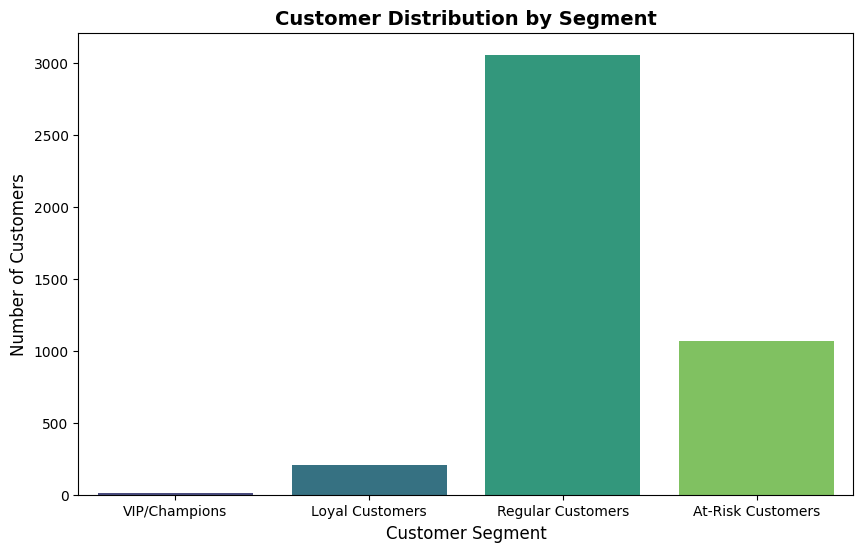

In [45]:
# Mapping clusters to meaningful names
cluster_names = {
    0: 'Regular Customers',
    1: 'At-Risk Customers',
    2: 'VIP/Champions',
    3: 'Loyal Customers'
}

rfm['ClusterName'] = rfm['Cluster'].map(cluster_names)

# Visualizing the distribution of clusters
plt.figure(figsize=(10, 6))
sns.countplot(x='ClusterName', data=rfm, palette='viridis', order=['VIP/Champions', 'Loyal Customers', 'Regular Customers', 'At-Risk Customers'])
plt.title('Customer Distribution by Segment', fontsize=14, fontweight='bold')
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.show()

In [46]:
# Item-Based Collaborative Filtering
# Creating a User-Item Matrix
# Rows = CustomerID, Columns = Description, Values = Quantity (or 1 if bought)

# Filtering to keep top 1000 most frequent customers to save memory
top_customers = df['CustomerID'].value_counts().head(1000).index
df_filtered = df[df['CustomerID'].isin(top_customers)]

# Creating a Pivot Table (User-Item Matrix)
user_item_matrix = df_filtered.pivot_table(index='CustomerID', columns='Description', values='Quantity', fill_value=0)

# BEST & FASTEST WAY: Converting to binary format (1 if bought, 0 if not)
# Yeh condition check karega aur seedha 0 ya 1 mein convert kar dega
user_item_matrix = (user_item_matrix > 0).astype(int)

print("User-Item Matrix created!")
print(f"Matrix shape: {user_item_matrix.shape}")

User-Item Matrix created!
Matrix shape: (1000, 3760)


Cosine Similarity


In [47]:
from sklearn.metrics.pairwise import cosine_similarity

print("Calculating item-to-item similarity using Cosine Similarity...")

# Transpose the matrix to calculate similarity between columns (products)
item_similarity = cosine_similarity(user_item_matrix.T)

# Convert the similarity matrix into a readable DataFrame with product names
item_similarity_df = pd.DataFrame(item_similarity, index=user_item_matrix.columns, columns=user_item_matrix.columns)

print("Item similarity matrix successfully created!")

# Core Function to get top N product recommendations
def get_recommendations(product_name, top_n=5):
    # Check if the product exists in our matrix
    if product_name not in item_similarity_df.columns:
        return f"Product '{product_name}' not found in the dataset matrix."
    
    # Fetch similarity scores for the specific product and sort them in descending order
    similarity_scores = item_similarity_df[product_name].sort_values(ascending=False)
    
    # Exclude the first item (since a product is always 100% similar to itself) and take top_n
    top_recommendations = similarity_scores.iloc[1:top_n+1]
    
    return top_recommendations

print("Recommendation engine function is ready for testing.")

Calculating item-to-item similarity using Cosine Similarity...
Item similarity matrix successfully created!
Recommendation engine function is ready for testing.


Testing the Recommendation System

In [48]:
# Testing the recommendation function with a popular item
sample_product = 'WHITE HANGING HEART T-LIGHT HOLDER'
print(f"Top 5 recommendations for '{sample_product}':")
print("-" * 60)
print(get_recommendations(sample_product))

Top 5 recommendations for 'WHITE HANGING HEART T-LIGHT HOLDER':
------------------------------------------------------------
Description
RED HANGING HEART T-LIGHT HOLDER     0.655155
CANDLEHOLDER PINK HANGING HEART      0.567734
HEART OF WICKER LARGE                0.539918
HEART OF WICKER SMALL                0.509600
WOODEN PICTURE FRAME WHITE FINISH    0.502706
Name: WHITE HANGING HEART T-LIGHT HOLDER, dtype: float64


Saving the Models for Streamlit App

In [49]:
import pickle

print("Saving models and dataframes for the Web App...")

# 1. Saving the trained KMeans model
with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans_model, f)

# 2. Saving the StandardScaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# 3. Saving the RFM dataframe as a CSV (for the segmentation module)
rfm.to_csv('rfm_data_for_app.csv', index=False)

# 4. Saving the Item Similarity Matrix (for the recommendation module)
item_similarity_df.to_pickle('item_similarity_matrix.pkl')

print("All files saved successfully! Your backend is 100% complete.")

Saving models and dataframes for the Web App...
All files saved successfully! Your backend is 100% complete.
